In [1]:
### Code to read in h5 files as detailed in the first guidebook
# Import necessary packages
import sys

sys.path.append(r"C:\Users\lwlav\.vscode\repo\BOEM-Oak-Island\Post_Processing_Scripts")
import pandas as pd
import os
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from scipy import signal
import glob
import utide
plt.rcParams.update({'font.size': 14}) 

deployment_num = [1,2,3,4,5]
sensor_spot = ["E", "C", "S"]
# directory_initial_user_path = r"/Volumes/BOEM/"  # Katherine
# directory_initial_user_path = r"/Volumes/kanarde/BOEM/"  # Brooke
directory_initial_user_path = r"Z:/"  # Levi

def tidal_ellipse(u,v,t,constituents = ['M2'], sensor = "S0",dep = "1",plotter = True):
 
    coef = utide.solve(t, u, v, lat=33.9, method="ols", conf_int="linear", constit=constituents)

    #With coefficients, we can reconstruct the tidal signal and plot the ellipses
    out = utide.reconstruct(t, coef)

    # Extract the fitted velocities
    u_fit = out.u
    v_fit = out.v
    if plotter == True:
        # Plotting the ellipse
        plt.figure(figsize=(6, 6))
        plt.plot(v_fit,u_fit, label='Reconstructed Tidal Ellipse')
        plt.axhline(0, color='black', lw=1, ls='--')
        plt.axvline(0, color='black', lw=1, ls='--')
        plt.xlabel("East Velocity (m/s)")
        plt.ylabel("North Velocity (m/s)")
        plt.title(f"Tidal Ellipse for {constituents[0]} - sensor {sensor} - Deployment {dep}")
        plt.axis('equal') # Crucial for seeing the true shape of the ellipse
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

    #Remove tidal ellipse from original signal to get residuals
    u_residual = u - u_fit
    v_residual = v - v_fit

    return coef, out, pd.DataFrame({
        "U_residual": u_residual,
        "V_residual": v_residual
    })


KeyboardInterrupt: 

In [ ]:
# Import bulkstats and create dictionary for each sensor
for dep in deployment_num:
    for spots in sensor_spot:
        initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
        sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
        for sensor_id in sensor_ids:
            sensor_location = os.path.basename(sensor_id)
            sensor_location = sensor_location.split("_")  # Extract S0 or S1
            sensor_serial = sensor_location[1]
            if sensor_serial == "103071" or dep ==5:
                files = ["DepthAveragedCurrentVelocity","Time","DepthAveragedEastVelocity","DepthAveragedNorthVelocity","Echo1avg"]
            else:
                files = ["DepthAveragedCurrentVelocity","Time","DepthAveragedEastVelocity","DepthAveragedNorthVelocity", "Vertavg"]
            waves = {}
            for file in files:
                file_path = os.path.join(sensor_id, file)  # file path
                df = pd.read_hdf(file_path)  # read the file into a Pandas dataframe
                file_name = file.split(".")[0]  # file name
                print(file_name)
                waves[file_name] = df  # store dataframe
            globals()[f"waves_{sensor_location[0]}_{dep}"] = waves
            

DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Echo1avg
DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Vertavg
DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Vertavg
DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Echo1avg
DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Vertavg
DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Vertavg
DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Vertavg
DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Echo1avg
DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Vertavg
DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Echo1avg
DepthAveragedCurrentVelocity
Time
DepthAverage

In [ ]:
###Low pass filter at 48hours to get subtidal flows
from spectral_sediment import lowpass_filter
for dep in deployment_num:
    for spots in sensor_spot:
        initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
        sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
        for sensor_id in sensor_ids:# Extract S0, S1, E1
            sensor_location = os.path.basename(sensor_id)
            sensor_location = sensor_location.split("_")[0]  # Extract S0 or S1
            print(f"Processing {sensor_location}...")
            waves = globals()[f"waves_{sensor_location}_{dep}"]
            coef, out, residuals = tidal_ellipse(waves["DepthAveragedEastVelocity"].values.squeeze(), 
                                              waves["DepthAveragedNorthVelocity"].values.squeeze(), 
                                              waves["Time"].values.squeeze(), 
                                              constituents=['M2'], 
                                              sensor=sensor_location, 
                                              dep=dep,
                                              plotter=False)
            waves['Tide_Residual_u'] = coef.umean
            waves['Tide_Residual_v'] = coef.vmean
            waves['MajorTidalAxis'] = coef['Lsmaj']
            waves['MinorTidalAxis'] = coef['Lsmin']
            waves['Theta'] = coef['theta']
            globals()[f"waves_{sensor_location}_{dep}"] = waves


Processing E1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing E1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing E0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing C0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing E1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing C0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S1...
solve: matrix prep ... 

[117.30754033]


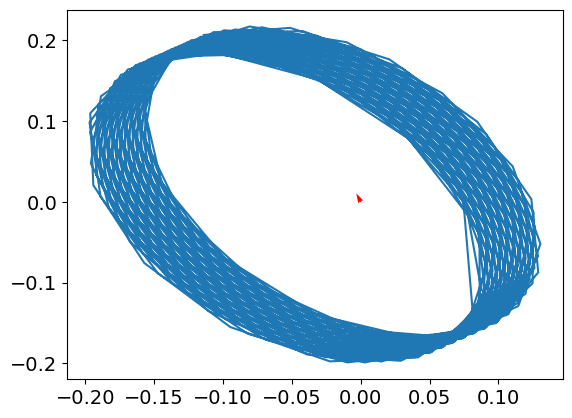

In [ ]:
print(waves['Theta'])
x = np.cos(np.radians(waves['Theta'])) *.01
y = np.sin(np.radians(waves['Theta'])) *.01

plt.plot(out.u, out.v, label='Reconstructed Tidal Ellipse')
plt.quiver(0,0,x,y, angles='uv', scale_units='xy', scale=1, color='r', label='Major Axis')
plt.show()

In [ ]:
import tabulate

#Create a few tables summarizing tidal spatial and temporal variability across deployments and sensors.
#South over East per deployment 

SvE = [["Deployment", 1,2,3,4],
        ["Locations", "S1/E1", "S1/E1", "S0/E0", "S1/E1"],
        ["Major Axis Difference (%)", (waves_S1_1["MajorTidalAxis"]/waves_E1_1["MajorTidalAxis"])[0],
         (waves_S1_2["MajorTidalAxis"]/waves_E1_2["MajorTidalAxis"])[0],
         (waves_S0_3["MajorTidalAxis"]/waves_E0_3["MajorTidalAxis"])[0],
         (waves_S1_4["MajorTidalAxis"]/waves_E1_4["MajorTidalAxis"])[0]],
        ["Minor Axis Difference (%)", (waves_S1_1["MinorTidalAxis"]/waves_E1_1["MinorTidalAxis"])[0],
         (waves_S1_2["MinorTidalAxis"]/waves_E1_2["MinorTidalAxis"])[0],
         (waves_S0_3["MinorTidalAxis"]/waves_E0_3["MinorTidalAxis"])[0],
         (waves_S1_4["MinorTidalAxis"]/waves_E1_4["MinorTidalAxis"])[0]]]

print(tabulate.tabulate(SvE, headers="firstrow", tablefmt="double_grid"))

Seasonal = [["Major Tidal Magnitude", "Summer-->Fall", "Fall-->Winter","Winter-->Spring", "Spring-->Summer", "Summer-->Fall"],
            ["S0", waves_S0_1['MajorTidalAxis'][0], waves_S0_2['MajorTidalAxis'][0], waves_S0_3['MajorTidalAxis'][0], 'N/A'],
            ["S1", waves_S1_1['MajorTidalAxis'][0], waves_S1_2['MajorTidalAxis'][0], 'N/A', waves_S1_4['MajorTidalAxis'][0], waves_S1_5['MajorTidalAxis'][0]],
            ["E0", 'N/A', 'N/A', waves_E0_3['MajorTidalAxis'][0],'N/A', 'N/A'],
            ["E1", waves_E1_1['MajorTidalAxis'][0], waves_E1_2['MajorTidalAxis'][0],'N/A',waves_E1_4['MajorTidalAxis'][0], None],
            ["C0", None, None, waves_C0_3['MajorTidalAxis'][0],None,waves_C0_5['MajorTidalAxis'][0]]]

print(tabulate.tabulate(Seasonal, headers="firstrow", tablefmt="double_grid", missingval="N/A"))



╔═══════════════════════════╦════════════════════╦════════════════════╦════════════════════╦════════════════════╗
║ Deployment                ║ 1                  ║ 2                  ║ 3                  ║ 4                  ║
╠═══════════════════════════╬════════════════════╬════════════════════╬════════════════════╬════════════════════╣
║ Locations                 ║ S1/E1              ║ S1/E1              ║ S0/E0              ║ S1/E1              ║
╠═══════════════════════════╬════════════════════╬════════════════════╬════════════════════╬════════════════════╣
║ Major Axis Difference (%) ║ 1.1084127934457157 ║ 1.1334382692986034 ║ 1.5421896377291395 ║ 1.6098973632514129 ║
╠═══════════════════════════╬════════════════════╬════════════════════╬════════════════════╬════════════════════╣
║ Minor Axis Difference (%) ║ 1.5930553087035004 ║ 1.6849107230643687 ║ 1.652481965598388  ║ 1.9166468621366235 ║
╚═══════════════════════════╩════════════════════╩════════════════════╩═════════════════

In [ ]:
#Mean Direction of Tidal Ellipse and how it changes across deployments and sensors
Thetas = [["Angle of Major Ellipse", "Summer-->Fall", "Fall-->Winter","Winter-->Spring", "Spring-->Summer", "Summer-->Fall"],
            ["S0", waves_S0_1['Theta'][0], waves_S0_2['Theta'][0], waves_S0_3['Theta'][0], 'N/A'],
            ["S1", waves_S1_1['Theta'][0], waves_S1_2['Theta'][0], 'N/A', waves_S1_4['Theta'][0],  waves_S1_5['Theta'][0]],
            ["E0", None, 'N/A', waves_E0_3['Theta'][0],'N/A', 'N/A'],
            ["E1", waves_E1_1['Theta'][0], waves_E1_2['Theta'][0],'N/A',waves_E1_4['Theta'][0], None],
            ["C0", None, None, waves_C0_3['Theta'][0],None,waves_C0_5['Theta'][0]]]

print(tabulate.tabulate(Thetas, headers="firstrow", tablefmt="double_grid",missingval="N/A"))

╔══════════════════════════╦═════════════════╦════════════════════╦════════════════════╦════════════════════╦════════════════════╗
║ Angle of Major Ellipse   ║   Summer-->Fall ║ Fall-->Winter      ║ Winter-->Spring    ║ Spring-->Summer    ║ Summer-->Fall      ║
╠══════════════════════════╬═════════════════╬════════════════════╬════════════════════╬════════════════════╬════════════════════╣
║ S0                       ║       144.188   ║ 166.48619456040942 ║ 154.96926168522742 ║ N/A                ║ N/A                ║
╠══════════════════════════╬═════════════════╬════════════════════╬════════════════════╬════════════════════╬════════════════════╣
║ S1                       ║       108.358   ║ 119.69931023918849 ║ N/A                ║ 122.46761177748894 ║ 117.30754032808676 ║
╠══════════════════════════╬═════════════════╬════════════════════╬════════════════════╬════════════════════╬════════════════════╣
║ E0                       ║       N/A       ║ N/A                ║ 176.52746498920

In [ ]:
#Look at Backscatter variability
#First calculate a bunch of representative statistics for each sensor and deployment, then make a table comparing them.
from spectral_sediment import despiker 

for dep in deployment_num:
    for spots in sensor_spot:
        initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
        sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
        for sensor_id in sensor_ids:# Extract S0, S1, E1
            sensor_location = os.path.basename(sensor_id)
            sensor_location = sensor_location.split("_")  # Extract S0 or S1
            print(f"Processing {sensor_location} for backscatter variability...")
            waves = globals()[f"waves_{sensor_location[0]}_{dep}"]
            file_name = "Echo1avg" if "Echo1avg" in waves else "Vertavg"
            echoavg = waves[file_name]
            if file_name == "Echo1avg":
                echoavg = despiker(despiker(echoavg, fs=2, lam=3)[0],fs=2, lam=2)[0]  # Despike according to goring and nikora
            if file_name == "Vertavg":
                echoavg = despiker(despiker(echoavg, fs=4, lam=3)[0],fs=4, lam=2)[0]  # Despike according to goring and nikora
            # Calculate variability
            mean_echo = np.mean(echoavg)
            std_echo = np.std(echoavg)
            waves['Echo_Variability'] = std_echo / mean_echo 

            # Calculate trend
            trend = signal.detrend(echoavg)
            waves['Echo_relTrend'] = (trend / mean_echo) * 100



Processing ['E1', '103071'] for backscatter variability...
Processing ['S0', '103080'] for backscatter variability...
Processing ['S1', '101418'] for backscatter variability...
Processing ['E1', '103071'] for backscatter variability...
Processing ['S0', '103080'] for backscatter variability...
Processing ['S1', '101418'] for backscatter variability...
Processing ['E0', '103080'] for backscatter variability...
Processing ['C0', '103071'] for backscatter variability...
Processing ['S0', '101418'] for backscatter variability...
Processing ['E1', '103071'] for backscatter variability...
Processing ['S1', '103080'] for backscatter variability...
Processing ['C0', '107730'] for backscatter variability...
Processing ['S1', '101481'] for backscatter variability...


In [ ]:
amplitudes = [["Variability", "Summer-->Fall", "Fall-->Winter","Winter-->Spring", "Spring-->Summer", "Summer-->Fall"],
             ['S0', waves_S0_1['Echo_Variability'], waves_S0_2['Echo_Variability'], waves_S0_3['Echo_Variability'], 'N/A'],
             ['S1', waves_S1_1['Echo_Variability'], waves_S1_2['Echo_Variability'], 'N/A', waves_S1_4['Echo_Variability'], waves_S1_5['Echo_Variability']],
             ['E0',None, None, waves_E0_3['Echo_Variability'],],
             ['E1',waves_E1_1['Echo_Variability'], waves_E1_2['Echo_Variability'],None, waves_E1_4['Echo_Variability'], None],
             ['C0', None, None, waves_C0_3['Echo_Variability'],None,waves_C0_5['Echo_Variability']]]

print(tabulate.tabulate(amplitudes, headers="firstrow", tablefmt="double_grid", missingval="N/A"))

╔═══════════════╦═════════════════╦═════════════════╦═════════════════════╦═════════════════════╦═════════════════╗
║ Variability   ║   Summer-->Fall ║   Fall-->Winter ║ Winter-->Spring     ║ Spring-->Summer     ║   Summer-->Fall ║
╠═══════════════╬═════════════════╬═════════════════╬═════════════════════╬═════════════════════╬═════════════════╣
║ S0            ║        0.31167  ║        0.611122 ║ 0.05180535879900894 ║ N/A                 ║     N/A         ║
╠═══════════════╬═════════════════╬═════════════════╬═════════════════════╬═════════════════════╬═════════════════╣
║ S1            ║        0.173974 ║        0.501552 ║ N/A                 ║ 0.1822569380626495  ║       0.0911851 ║
╠═══════════════╬═════════════════╬═════════════════╬═════════════════════╬═════════════════════╬═════════════════╣
║ E0            ║      N/A        ║      N/A        ║ 0.06267692410276324 ║ N/A                 ║     N/A         ║
╠═══════════════╬═════════════════╬═════════════════╬═══════════════════

In [ ]:
#Attempt to calculate coherence
def coherence_spectrum(u, v, A, fs, NW=3.0, Kmax=None, smooth_bins=7):
    from scipy.signal.windows import dpss
    """
    Multitaper coherence between U = u + i v and scalar A.

    u, v, A : 1D arrays (same length, same sampling)
    fs      : sampling rate (Hz)
    NW      : time-bandwidth product
    Kmax    : number of tapers (defaults to 2*NW - 1)
    smooth_bins : integer, moving-average smoothing in frequency
    """
    u = np.asarray(u, float).ravel().copy()
    v = np.asarray(v, float).ravel().copy()
    A = np.asarray(A, float).ravel().copy()

    U = u + 1j * v

    # Demean & fill NaNs
    U -= np.nanmean(U)
    A -= np.nanmean(A)
    U = np.nan_to_num(U, nan=0.0)
    A = np.nan_to_num(A, nan=0.0)

    N = len(U)

    if Kmax is None:
        Kmax = int(2*NW - 1)

    tapers, eigs = dpss(N, NW, Kmax, return_ratios=True)

    Sxx = np.zeros(N, float)
    Syy = np.zeros(N, float)
    Sxy = np.zeros(N, complex)

    for k in range(Kmax):
        Uk = U * tapers[k]
        Ak = A * tapers[k]

        Xk = np.fft.fft(Uk)
        Yk = np.fft.fft(Ak)

        Sxx += np.abs(Xk)**2
        Syy += np.abs(Yk)**2
        Sxy += Yk * np.conj(Xk)

    Sxx /= Kmax
    Syy /= Kmax
    Sxy /= Kmax

    # Frequency smoothing
    if smooth_bins > 1:
        kern = np.ones(smooth_bins) / smooth_bins
        Sxx = np.convolve(Sxx, kern, mode="same")
        Syy = np.convolve(Syy, kern, mode="same")
        Sxy = np.convolve(Sxy, kern, mode="same")

    eps = 1e-12
    Coh_complex = Sxy / (np.sqrt(Sxx * Syy) + eps)

    f = np.fft.fftfreq(N, d=1/fs)
    pos = f > 0
    neg = f < 0
    f1 = f[neg]
    f = f[pos]
    Coh_complexp = Coh_complex[pos]
    Coh_complexn = Coh_complex[neg]

    Coh_magp = np.abs(Coh_complexp)
    Coh_magn = np.abs(Coh_complexn)
    Coh_phase = np.angle(Coh_complex)

    return f,f1, Coh_magp, Coh_magn, Coh_phase

def downsample_antialias(signal, fs, fs_new, order=4):
    from scipy.signal import butter, filtfilt

    signal = np.asarray(signal).squeeze().astype(float)

    if fs_new >= fs:
        raise ValueError("fs_new must be smaller than fs")

    # Integer decimation factor
    q = int(np.round(fs / fs_new))
    fs_eff = fs / q

    # Butterworth low-pass filter just below new Nyquist
    fc = 0.45 * fs_eff  # cutoff Hz
    b, a = butter(order, fc / (0.5 * fs), btype="low")

    # Adaptive pad length for safety
    padlen = min(3 * max(len(a), len(b)), signal.size - 1)

    y_filt = filtfilt(b, a, signal, padlen=padlen)
    y_ds = y_filt[::q]

    return y_ds, fs_eff


In [ ]:
# Import bulkstats and create dictionary for each sensor
from spectral_sediment import despiker 

for dep in deployment_num:
    for spots in sensor_spot:
        initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
        sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
        for sensor_id in sensor_ids:
            sensor_location = os.path.basename(sensor_id)
            sensor_location = sensor_location.split("_")  # Extract S0 or S1
            sensor_serial = sensor_location[1]
            if sensor_serial == "103071" or dep ==5:
                files = ["Time","FullEastVelocity","FullNorthVelocity","Echo1avg"]
            else:
                files = ["Time","FullEastVelocity","FullNorthVelocity", "Vertavg"]
            waves = {}
            print("Reading files for sensor:", sensor_location, "Deployment:", dep)
            for file in files:
                file_path = os.path.join(sensor_id, file)  # file path
                df = pd.read_hdf(file_path)  # read the file into a Pandas dataframe
                file_name = file.split(".")[0]  # file name
                waves[file_name] = df  # store dataframe
            globals()[f"waves_{sensor_location[0]}_{dep}"] = waves
            print(waves['FullEastVelocity'].shape, waves['FullNorthVelocity'].shape, waves[file_name].shape)
        #Despike and downsample so echo and velocity data are at the same frequency
            file_name = "Echo1avg" if "Echo1avg" in waves else "Vertavg"
            print("Despiking")
            echoavg = waves[file_name]
            if file_name == "Echo1avg":
                echoavg = despiker(despiker(echoavg, fs=2, lam=3)[0],fs=2, lam=2)[0]  # Despike according to goring and nikora
                u = despiker(despiker(waves['FullEastVelocity'], fs=2, lam=3)[0],fs=2, lam=2)[0]
                v = despiker(despiker(waves['FullNorthVelocity'], fs=2, lam=3)[0],fs=2, lam=2)[0]
            if file_name == "Vertavg":
                echoavg = despiker(despiker(echoavg, fs=4, lam=3)[0],fs=4, lam=2)[0]  # Despike according to goring and nikora
                u = despiker(despiker(waves['FullEastVelocity'], fs=4, lam=3)[0],fs=4, lam=2)[0]
                v = despiker(despiker(waves['FullNorthVelocity'], fs=4, lam=3)[0],fs=4, lam=2)[0]
            print("Coherence...")
            fp, fn, Coh_magp, Coh_magn, Coh_phase = coherence_spectrum(u,v,echoavg,fs=2,NW=3.0, smooth_bins=7)
            print("Saving")
            pd.save_hdf(pd.DataFrame({
                "Frequencyp": fp,
                "Coherencep": Coh_magp,
                "Coherencen": Coh_magn,
                "Frequencyn": fn,
                "Phase": Coh_phase
            }), os.path.join(initpath, sensor_id, "CoherenceSpectrum.h5"))


Reading files for sensor: ['E1', '103071'] Deployment: 1
(5018400, 1) (5018400, 1) (5117290, 1)
Despiking
Coherence...


ValueError: operands could not be broadcast together with shapes (5117290,) (5018400,) 